In [1]:
import numpy as np
import pandas as pd

In [2]:
data = np.load("./data/processed/dataset_full.npz", allow_pickle=True)
X_full = data["X"]

In [3]:
X_full.shape

(6205696, 30)

In [4]:
df = pd.DataFrame(X_full, columns=[f"F{i}" for i in range(30)])

corr_matrix = df.corr()

print(corr_matrix)

           F0        F1        F2        F3        F4        F5        F6  \
F0   1.000000  0.066426  0.008150 -0.003534  0.932904  0.059936  0.006630   
F1   0.066426  1.000000  0.998300  0.997550  0.133596 -0.619021  0.000950   
F2   0.008150  0.998300  1.000000  0.999932  0.079386 -0.623872  0.000564   
F3  -0.003534  0.997550  0.999932  1.000000  0.068488 -0.624589  0.000487   
F4   0.932904  0.133596  0.079386  0.068488  1.000000  0.005001  0.007107   
F5   0.059936 -0.619021 -0.623872 -0.624589  0.005001  1.000000  0.000036   
F6   0.006630  0.000950  0.000564  0.000487  0.007107  0.000036  1.000000   
F7  -0.063240  0.954225  0.960000  0.960765  0.001971 -0.603208  0.074488   
F8  -0.063311  0.954136  0.959915  0.960681  0.001887 -0.603039  0.028921   
F9   0.006630  0.000950  0.000564  0.000487  0.007107  0.000036 -0.298654   
F10  0.007619  0.000506  0.000062 -0.000027  0.007108  0.000457  0.999986   
F11  0.045132 -0.455685 -0.459315 -0.459855  0.004140  0.629968 -0.221049   

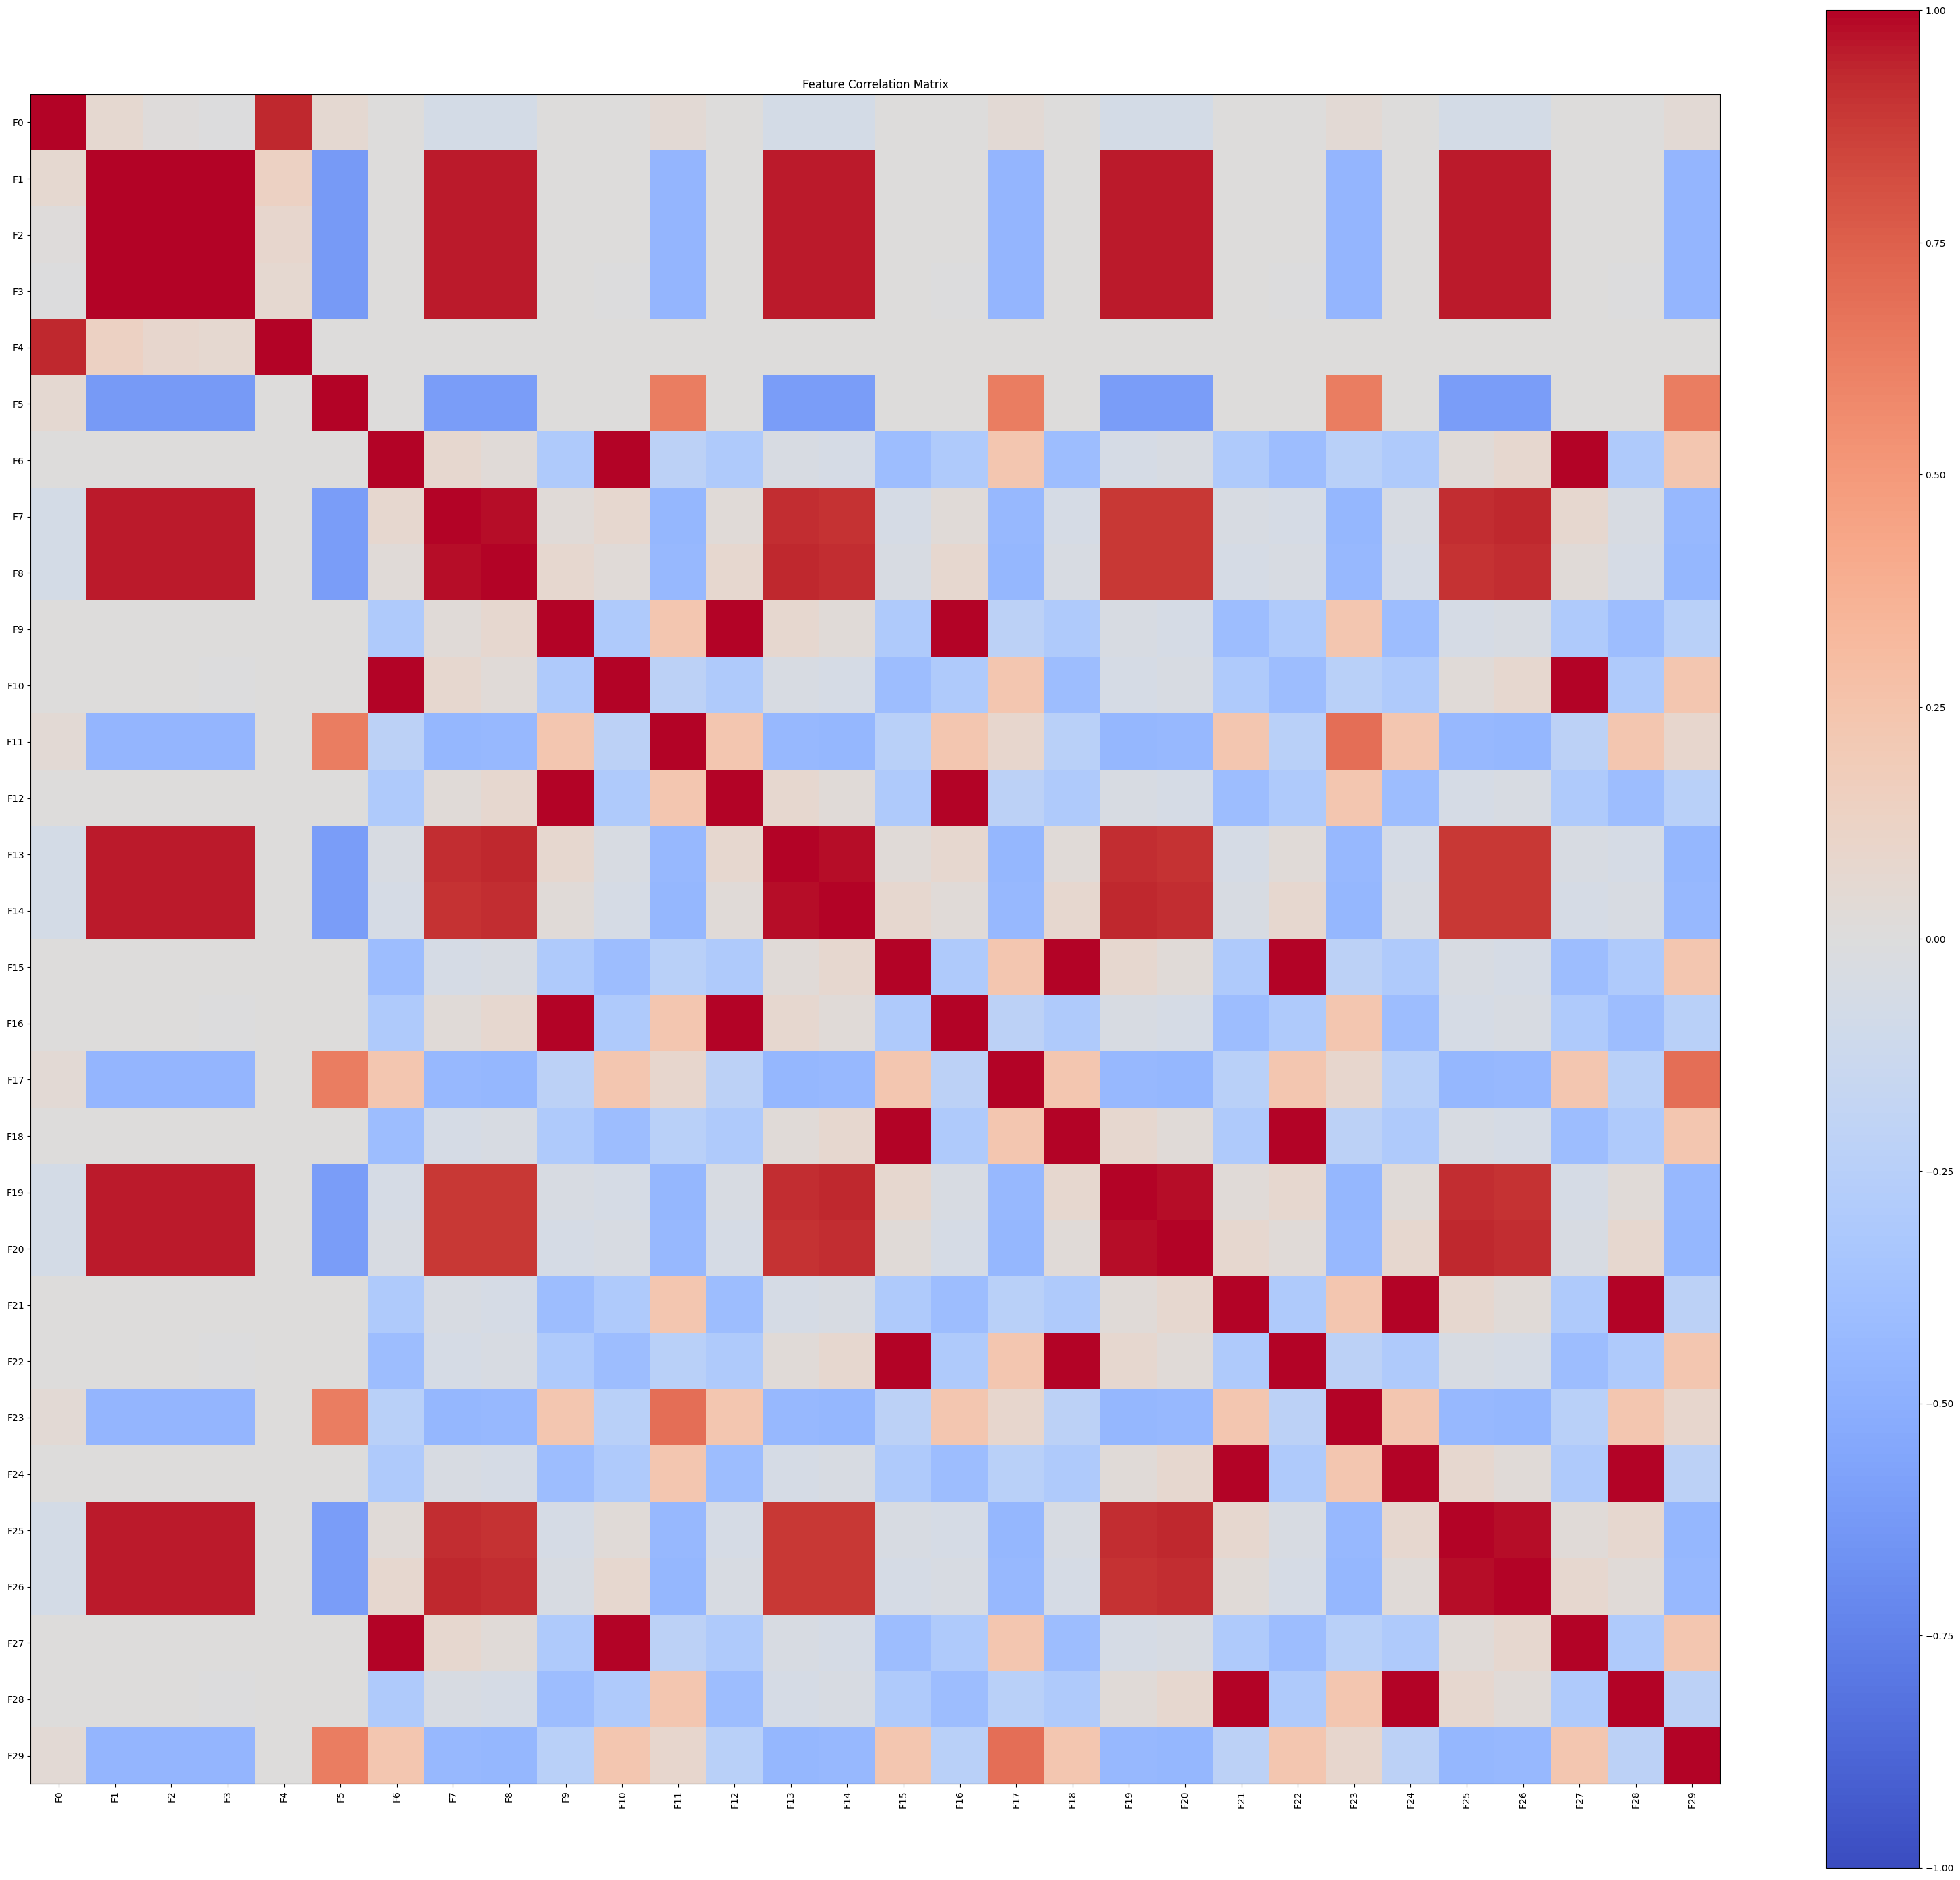

In [5]:
import matplotlib.pyplot as plt


plt.figure(figsize=(32,28))

plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1,vmax=1)

plt.colorbar()

feature_names = [f"F{i}" for i in range(30)]

plt.xticks(range(len(feature_names)), feature_names, rotation=90)
plt.yticks(range(len(feature_names)), feature_names)

plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

In [6]:
corr_matrix = df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print("Features to remove:", to_drop)

Features to remove: ['F2', 'F3', 'F4', 'F7', 'F8', 'F10', 'F12', 'F13', 'F14', 'F16', 'F18', 'F19', 'F20', 'F22', 'F24', 'F25', 'F26', 'F27', 'F28']


In [7]:
import numpy as np

matrix = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])

print("Original matrix:")
print(matrix)

print("\nUpper triangle (k=0):")
print(np.triu(matrix))

print("\nUpper triangle (k=-1):")
print(np.triu(matrix, -1))   

Original matrix:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

Upper triangle (k=0):
[[1 2 3]
 [0 5 6]
 [0 0 9]]

Upper triangle (k=-1):
[[1 2 3]
 [4 5 6]
 [0 8 9]]


In [8]:
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs.sort_values(ascending=False)

print(corr_pairs[30:50])

F23  F23    1.000000
F24  F21    1.000000
     F24    1.000000
F22  F22    1.000000
F4   F4     1.000000
F21  F24    1.000000
     F21    1.000000
F20  F20    1.000000
F28  F21    0.999986
     F24    0.999986
F24  F28    0.999986
F21  F28    0.999986
F6   F10    0.999986
F10  F6     0.999986
F27  F10    0.999986
F22  F18    0.999986
F15  F22    0.999986
F18  F22    0.999986
F10  F27    0.999986
F22  F15    0.999986
dtype: float64


In [9]:
df_reduced = df.drop(columns=to_drop)
df_reduced.shape

(6205696, 11)

In [10]:
list(df_reduced.columns)

['F0', 'F1', 'F5', 'F6', 'F9', 'F11', 'F15', 'F17', 'F21', 'F23', 'F29']

In [11]:
cols = [0,1,5,6,9,11,15,17,21,23,29]
X_filtered = X_full[:, cols]

In [12]:
X_filtered.shape

(6205696, 11)

In [16]:
import os
OUT_DIR = "./data/processed"
os.makedirs(OUT_DIR, exist_ok=True)

K0_PHASE_C = 4.67
K0_PHASE_A = 4.93
K0_EPS = 1e-6
DOWNSAMPLE = 20


y_full = data["y"]
K0_full = data["K0"]

X_uncorr = np.asarray(X_filtered)
y_full = np.asarray(y_full, dtype=object)
K0_full = np.asarray(K0_full)

np.savez(
    os.path.join(OUT_DIR, "dataset_full_UNCORR.npz"),
    X=X_uncorr,
    y=y_full,
    K0=K0_full
)

print("dataset_full_UNCORR.npz zapisany")

#print("X_full shape:", X_full.shape)
mask_train = (
    (K0_full == K0_PHASE_C) |
    (K0_full == K0_PHASE_A)
) & (y_full != None)

X_train = X_uncorr[mask_train]
y_train = y_full[mask_train].astype(int)
K0_train = K0_full[mask_train]

# downsampling
idx = np.arange(len(X_train)) % DOWNSAMPLE == 0

X_train = X_train[idx]
y_train = y_train[idx]
K0_train = K0_train[idx]

np.savez(
    os.path.join(OUT_DIR, "dataset_train_shortened_UNCORR.npz"),
    X=X_train,
    y=y_train,
    K0=K0_train
)

print("dataset_train_shortened_UNCORR.npz zapisany")
print("X_train shape:", X_train.shape)


dataset_full_UNCORR.npz zapisany
X_full shape: (6205696, 30)
dataset_train_shortened_UNCORR.npz zapisany
X_train shape: (47222, 11)
